In [ ]:
# importing dataset

In [6]:
import kagglehub

path = kagglehub.dataset_download("aadharshviswanath/flight-data")
print("Dataset path:", path)

100%|██████████| 143k/143k [00:00<00:00, 42.0MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/aadharshviswanath/flight-data/versions/20


In [7]:
path = kagglehub.dataset_download("aadharshviswanath/flight-data")
print(path)

Using Colab cache for faster access to the 'flight-data' dataset.
/kaggle/input/flight-data


In [8]:
import os
print(os.listdir(path))

['.nfs000000001b5400bc000000a8', 'flight_data.csv']


In [9]:
import pandas as pd
file_path= os.path.join(path,"flight_data.csv" )
df=pd.read_csv(file_path)
df.head()

,Flight_ID,Date,Time,Departure_Airport,Arrival_Airport,Temperature_Celsius,Wind_Speed_knots,Turbulence_Level,Visibility_km
0,142,2024-10-11,10:25,ATL Airport,SEA Airport,35,45,High,19
1,110,2024-01-20,18:38,IAH Airport,AUS Airport,3,25,Low,6
2,113,2024-12-26,12:50,STL Airport,SEA Airport,20,48,Medium,6
3,3,2024-08-19,07:28,MCO Airport,LAS Airport,33,48,High,18
4,22,2024-12-07,07:10,LAX Airport,SEA Airport,28,34,Low,20


In [ ]:
# exploring dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Flight_ID            10000 non-null  int64 
 1   Date                 10000 non-null  object
 2   Time                 10000 non-null  object
 3   Departure_Airport    10000 non-null  object
 4   Arrival_Airport      10000 non-null  object
 5   Temperature_Celsius  10000 non-null  int64 
 6   Wind_Speed_knots     10000 non-null  int64 
 7   Turbulence_Level     10000 non-null  object
 8   Visibility_km        10000 non-null  object
dtypes: int64(3), object(6)
memory usage: 703.3+ KB


In [11]:
df.columns

Index(['Flight_ID', 'Date', 'Time', 'Departure_Airport', 'Arrival_Airport',
       'Temperature_Celsius', 'Wind_Speed_knots', 'Turbulence_Level',
       'Visibility_km'],
      dtype='object')

In [ ]:
# Creating safety label

In [12]:
df["Turbulence_Level"].value_counts()

,count
Turbulence_Level,
High,3400
Low,3342
Medium,3258


In [13]:
df["Visibility_km"].value_counts()

,count
Visibility_km,
6,571
3,543
14,524
17,523
20,519
5,518
13,512
12,511
16,501


In [14]:
def classify_safety(row):
  if row["Turbulence_Level"]=="High":
    return 1

    if int(row["Visibility_km"]) <=5:
      return 1
      return 0

df["Safety_Label"]=df.apply(classify_safety,axis=1)


In [15]:
df["Safety_Label"].value_counts()

,count
Safety_Label,
1.0,3400


In [ ]:
#3400 rows out of the 10,000 rows are labeled and the 6,600 rows left are unlabeled because ( visibility_km) is still counted as an object/string

In [16]:
import pandas as pd
df["Visibility_km"]=pd.to_numeric(df["Visibility_km"], errors="coerce")

In [18]:
df["Visibility_km"].isna().sum()

np.int64(1)

In [ ]:
#recreating the safety label

In [24]:
import pandas as pd
df["Visibility_km"]=pd.to_numeric(df["Visibility_km"], errors="coerce")

In [26]:
df["Safety_Label"] = 0

df.loc[
    (df["Turbulence_Level"] == "High") |
    (df["Visibility_km"] <= 5),
    "Safety_Label"
] = 1


In [28]:
df["Safety_Label"].value_counts()

,count
Safety_Label,
1,5052
0,4948


In [ ]:
# Building the model

In [ ]:
# Preparing features

In [29]:
features= [
    "Temperature_Celsius",
    "Wind_Speed_knots",
    "Turbulence_Level",
    "Visibility_km"
]

X=df[features]
y= df["Safety_Label"]

In [ ]:
# Encoding turbulence

In [31]:
X = pd.get_dummies(X, columns=["Turbulence_Level"], drop_first=True)

In [ ]:
# Train - test split

In [32]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test= train_test_split(
    X,y, test_size=0.2 , random_state=42 , stratify=y
)

In [ ]:
# Training the random forest model

In [ ]:
# Importing and creating the model

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [ ]:
# Training the model

In [34]:
rf_model.fit(X_train , y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Evaluating the model

In [36]:
from sklearn.metrics import accuracy_score
y_pred= rf_model.predict(X_test)
accuracy= accuracy_score(y_test , y_pred)

print("Accuracy:",accuracy)

Accuracy: 1.0


In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       990
           1       1.00      1.00      1.00      1010

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [43]:
df.corr(numeric_only=True)["Safety_Label"].sort_values(ascending=False)

,Safety_Label
Safety_Label,1.000000
Flight_ID,0.002181
Wind_Speed_knots,0.000140
Temperature_Celsius,-0.007882
Visibility_km,-0.416968


In [ ]:
# Feature importance

In [47]:
import pandas as pd
feature_importance= pd.Series(
    rf_model.feature_importances_,
    index=X.columns
    ).sort_values(ascending=False)


In [41]:
feature_importance

,0
Visibility_km,0.383626
Turbulence_Level_Low,0.305287
Turbulence_Level_Medium,0.303798
Temperature_Celsius,0.003742
Wind_Speed_knots,0.003548


In [ ]:
# Visualization

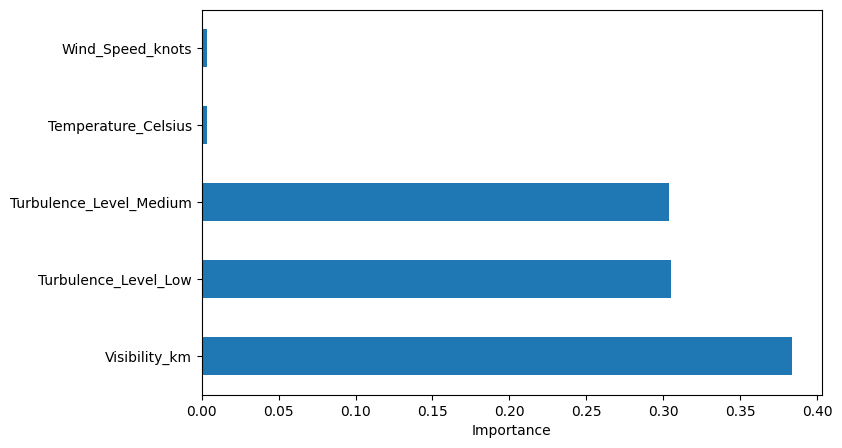

In [48]:
import matplotlib.pyplot as plt

feature_importance.plot(kind='barh', figsize=(8,5))
plt.title=("Feature Importance For Aviation Safety Prediction")
plt.xlabel("Importance")
plt.show()